# Kernel SVM
- Kernel Support Vector Machine (Kernel SVM) is an extension of the traditional SVM algorithm, designed to handle non-linearly separable data by transforming it into a higher-dimensional space. This transformation enables SVM to find a linear boundary in this new space, which corresponds to a non-linear boundary in the original space.

#### Intuition:
- Assuming we have two groups of points on a 2D plane that cannot be separated by a straight line. By applying the kernel trick, Kernel SVM "lifts" these points into a higher dimension (like a 3D plane), where a straight line (hyperplane) can separate them. When viewed back in the original 2D space, this separation appears as a curved boundary.

- Kernel SVM enables SVM to solve non-linear classification problems by implicitly mapping data to a higher-dimensional space, where a linear separation becomes possible. Its versatility and efficiency make it one of the most powerful classification tools for complex datasets.

#### Key Concepts:
1. The Problem with Non-Linearity:
    - Standard SVM can only create linear decision boundaries.
    
    - In many real-world problems, the data points are not linearly separable (e.g., forming concentric circles or other non-linear patterns).

2. Kernel Trick:
    - Instead of explicitly transforming the data into a higher-dimensional space (which can be computationally expensive), the kernel trick computes the relationships between data points in the higher-dimensional space directly, using a kernel function.

    - This avoids the need for the actual transformation, making the process computationally efficient.

3. How It Works:
    - A kernel function calculates the similarity between two data points in the original space as if they were in the higher-dimensional space.

    - SVM then uses this similarity to construct the optimal hyperplane in the transformed space.

#### Common Kernel Functions:
1. Linear Kernel:
    - Suitable for linearly separable data.

2. Polynomial Kernel:
    - Allows the model to fit polynomial decision boundaries.

3. Radial Basis Function (RBF) or Gaussian Kernel:
    - Handles complex, non-linear boundaries by creating a smooth curve around data points.

    - Most commonly used in 'Kernel SVM'.

4. Sigmoid Kernel:
    - Mimics neural networks and is less commonly used.

#### Use Cases of Kernel SVM:
1. Image Recognition:
    - Distinguishing between objects in images with complex shapes.

2. Natural Language Processing:
    - Sentiment analysis and text classification.

3. Bioinformatics:
    - Identifying patterns in genetic data.

4. Medical Diagnosis:
    - Predicting diseases based on non-linear relationships between symptoms.

#### Advantages:
1. Handles Non-Linearity:
    - Effectively classifies data that is not linearly separable.

2. Flexibility:
    - Different kernels can be chosen depending on the problem's complexity.

3. Scalability:
    - Works for both low-dimensional and high-dimensional data.

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

## Loading the data

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


## Splitting the dataset into training and test sets

In [3]:
from sklearn.model_selection import train_test_split

X = dataset.iloc[:, :2].values
y = dataset.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature scaling

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Kernel SVM model on the training set

In [5]:
from sklearn.svm import SVC

classifier = SVC(kernel = 'rbf', random_state = 0, verbose=True)
classifier.fit(X_train, y_train)

[LibSVM]*
optimization finished, #iter = 179
obj = -77.780723, rho = 0.252286
nSV = 94, nBSV = 79
Total nSV = 94


SVC(random_state=0, verbose=True)

## Predicting a new result

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


## Predicting the test result

In [7]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]]


## Making the confusion matrix

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
# Summary Table
cm_table = pd.DataFrame(cm, index=['Wrong Prediction', 'Correct Prediction'], columns=['Predicted No', 'Predicted Yes'])
cm_table

,Predicted No,Predicted Yes
Wrong Prediction,55,3
Correct Prediction,1,21


## Calculating the accuracy score

In [9]:
from sklearn.metrics import accuracy_score

print(f'Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Model Accuracy: 95.00%


## Visualizing the training set results

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_24154/2711413357.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


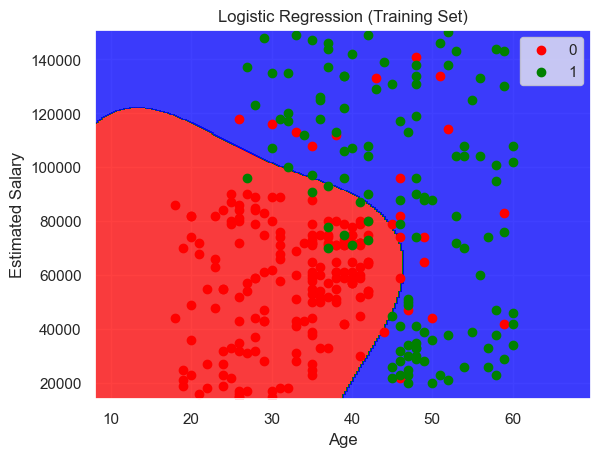

In [10]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap


X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))


plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualizing the test set results

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_24154/1048508887.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


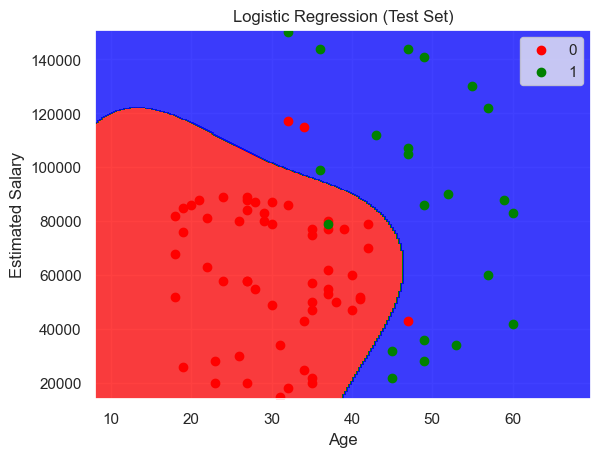

In [11]:
from matplotlib.colors import ListedColormap


X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))


plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)

plt.title('Logistic Regression (Test Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()